In [9]:
import os
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype


def compare_npz(file1, file2, float_rtol=1e-6, float_atol=1e-8, verbose=True):
    data1 = np.load(file1, allow_pickle=False)
    data2 = np.load(file2, allow_pickle=False)

    keys1 = sorted(data1.files)
    keys2 = sorted(data2.files)

    only_in_file1 = sorted(set(keys1) - set(keys2))
    only_in_file2 = sorted(set(keys2) - set(keys1))
    common_keys = sorted(set(keys1) & set(keys2))

    all_same = True

    if verbose:
        print("=== NPZ 欄位檢查 ===")
        if only_in_file1:
            print("只在 file1 出現的 keys:", only_in_file1)
        if only_in_file2:
            print("只在 file2 出現的 keys:", only_in_file2)
        if not only_in_file1 and not only_in_file2:
            print("兩邊的 keys 集合相同")

    if only_in_file1 or only_in_file2:
        all_same = False

    if verbose:
        print("=== NPZ 共同 keys 內容比較 ===")

    if not common_keys:
        if verbose:
            print("沒有共同 keys，無法進一步比較內容")
        return False

    for k in common_keys:
        arr1 = data1[k]
        arr2 = data2[k]

        if arr1.shape != arr2.shape:
            if verbose:
                print(f"[{k}] shape 不同: {arr1.shape} vs {arr2.shape}")
            all_same = False
            continue

        if arr1.dtype != arr2.dtype:
            if verbose:
                print(f"[{k}] dtype 不同: {arr1.dtype} vs {arr2.dtype}")
            all_same = False

        if np.issubdtype(arr1.dtype, np.floating) and np.issubdtype(arr2.dtype, np.floating):
            same = np.allclose(arr1, arr2, rtol=float_rtol, atol=float_atol, equal_nan=True)
        else:
            same = np.array_equal(arr1, arr2, equal_nan=True)

        if not same:
            if verbose:
                print(f"[{k}] 內容不同")
            all_same = False

    if verbose:
        if all_same:
            print("兩個 .npz 檔案在 keys 與共同內容上完全相同")
        else:
            print("兩個 .npz 檔案有差異（上方已列出）")

    return all_same


def compare_parquet(
    file1,
    file2,
    ignore_row_order=False,
    ignore_column_order=False,
    float_rtol=1e-6,
    float_atol=1e-8,
    verbose=True,
):
    df1 = pd.read_parquet(file1)
    df2 = pd.read_parquet(file2)

    cols1 = df1.columns.tolist()
    cols2 = df2.columns.tolist()

    only_in_file1 = sorted(set(cols1) - set(cols2))
    only_in_file2 = sorted(set(cols2) - set(cols1))
    common_cols = [c for c in cols1 if c in set(cols2)]

    all_same = True

    if verbose:
        print("=== Parquet 欄位檢查 ===")
        if only_in_file1:
            print("只在 file1 出現的 columns:", only_in_file1)
        if only_in_file2:
            print("只在 file2 出現的 columns:", only_in_file2)
        if not only_in_file1 and not only_in_file2:
            print("兩邊的 columns 集合相同")

    if only_in_file1 or only_in_file2:
        all_same = False

    if not common_cols:
        if verbose:
            print("沒有共同欄位，無法進一步比較內容")
        return False

    if ignore_column_order:
        common_cols = sorted(common_cols)

    df1_common = df1[common_cols].copy()
    df2_common = df2[common_cols].copy()

    if df1.shape[0] != df2.shape[0]:
        if verbose:
            print("Parquet 列數不同:", df1.shape[0], "vs", df2.shape[0])
        all_same = False

    if verbose:
        print("=== Parquet 共同欄位內容比較 ===")

    if ignore_row_order:
        sortable_cols = common_cols.copy()
        df1_common = df1_common.sort_values(by=sortable_cols).reset_index(drop=True)
        df2_common = df2_common.sort_values(by=sortable_cols).reset_index(drop=True)
    else:
        if not df1_common.index.equals(df2_common.index):
            if verbose:
                print("Parquet index 不同")
            all_same = False

    for col in common_cols:
        s1 = df1_common[col]
        s2 = df2_common[col]

        if s1.dtype != s2.dtype:
            if verbose:
                print(f"[{col}] dtype 不同: {s1.dtype} vs {s2.dtype}")
            all_same = False

        if is_numeric_dtype(s1) and is_numeric_dtype(s2):
            same = np.allclose(
                s1.to_numpy(),
                s2.to_numpy(),
                rtol=float_rtol,
                atol=float_atol,
                equal_nan=True,
            )
        else:
            same = s1.equals(s2)

        if not same:
            if verbose:
                print(f"[{col}] 內容不同")
                diff_mask = ~(s1.eq(s2) | (s1.isna() & s2.isna()))
                diff_rows = diff_mask[diff_mask].index.tolist()[:5]
                if diff_rows:
                    print("前幾個不同的位置與值:")
                    for idx in diff_rows:
                        print(f"  index={idx}, file1={s1.loc[idx]!r}, file2={s2.loc[idx]!r}")
            all_same = False

    if verbose:
        if all_same:
            print("兩個 .parquet 檔案在欄位與共同欄位內容上完全相同")
        else:
            print("兩個 .parquet 檔案有差異（上方已列出）")

    return all_same


def compare_files(
    file1,
    file2,
    ignore_row_order=False,
    ignore_column_order=False,
    float_rtol=1e-6,
    float_atol=1e-8,
    verbose=True,
):
    ext1 = os.path.splitext(file1)[1].lower()
    ext2 = os.path.splitext(file2)[1].lower()

    if ext1 != ext2:
        raise ValueError(f"檔案類型不同，不能比較: {ext1} vs {ext2}")

    if ext1 == ".npz":
        return compare_npz(
            file1,
            file2,
            float_rtol=float_rtol,
            float_atol=float_atol,
            verbose=verbose,
        )

    if ext1 == ".parquet":
        return compare_parquet(
            file1,
            file2,
            ignore_row_order=ignore_row_order,
            ignore_column_order=ignore_column_order,
            float_rtol=float_rtol,
            float_atol=float_atol,
            verbose=verbose,
        )

    raise ValueError(f"目前不支援的檔案類型: {ext1}")

In [10]:
compare_files("../data/preprocessed_data/old_xgb_dataset/xgb_dataset_eval.parquet", "../data/preprocessed_data/xgb_dataset_long_eval.parquet")

=== Parquet 欄位檢查 ===
只在 file1 出現的 columns: ['close', 'cost_20d', 'cost_60d', 'high_ret', 'low_ret', 'net_buy']
=== Parquet 共同欄位內容比較 ===
兩個 .parquet 檔案有差異（上方已列出）


False

In [4]:
import numpy as np

# 載入模型參數
data = np.load('../outputs/exp3/states_10/trained_hmm_params.npz')

# print("transition matrix:")
# print(data['transmat'])

means = data['means']
covars = data['covars']  # shape: (5, 5, 5)

# 從共變異數矩陣的對角線提取變異數，再開根號得到標準差
std_devs = np.sqrt(np.diagonal(covars, axis1=1, axis2=2))
features = ['z_t', 'c_t', 'a_t', 's_t', 'm_t']

for i in range(10):
    print(f"\n=== State {i} ===")
    for j, feature in enumerate(features):
        print(f"  {feature:<4}: Mean = {means[i][j]:>6.3f}, Std = {std_devs[i][j]:>6.3f}")


=== State 0 ===
  z_t : Mean = -0.055, Std =  0.053
  c_t : Mean = -1.000, Std =  0.000
  a_t : Mean =  0.105, Std =  0.069
  s_t : Mean = -0.361, Std =  0.472
  m_t : Mean = -0.024, Std =  0.043

=== State 1 ===
  z_t : Mean =  0.021, Std =  0.018
  c_t : Mean =  2.000, Std =  0.000
  a_t : Mean =  0.036, Std =  0.024
  s_t : Mean =  0.225, Std =  0.406
  m_t : Mean =  0.005, Std =  0.012

=== State 2 ===
  z_t : Mean =  0.000, Std =  0.000
  c_t : Mean =  0.000, Std =  0.000
  a_t : Mean =  0.003, Std =  0.017
  s_t : Mean = -0.004, Std =  0.241
  m_t : Mean =  0.000, Std =  0.012

=== State 3 ===
  z_t : Mean = -0.023, Std =  0.019
  c_t : Mean = -2.000, Std =  0.000
  a_t : Mean =  0.037, Std =  0.025
  s_t : Mean = -0.241, Std =  0.402
  m_t : Mean = -0.005, Std =  0.012

=== State 4 ===
  z_t : Mean =  0.054, Std =  0.050
  c_t : Mean =  1.000, Std =  0.000
  a_t : Mean =  0.105, Std =  0.065
  s_t : Mean =  0.366, Std =  0.468
  m_t : Mean =  0.024, Std =  0.042

=== State 5 ==

In [2]:
import os
from dotenv import load_dotenv
from FinMind.data import DataLoader
import pandas as pd
import json
import numpy as np
from hmmlearn.hmm import GaussianHMM
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

## FINMIND API

In [43]:
stock_set = set()
for trader_id in [1360, 1400, 1440, 1470, 1480, 1560, 1650, 1660, 7030, 8440, 8960]:
    df = pd.read_parquet(f"../data/brokers/{trader_id}/2021-06-30_to_2026-02-11.parquet")
    # df[df["stock_id"] == "0050"]
    unique_values = set(df["stock_id"].unique())
    stock_set |= unique_values

In [48]:
with open("stock_ids.json", "w") as f:
    json.dump(list(stock_set), f, indent=4)

In [38]:
lengths = np.load("../data/preprocessed_data/hmm_lengths.npy")
lengths[:10]

array([ 64, 239, 209, 232,  79, 165,  82, 148,  53, 104])

In [32]:
(64+239+209+232+79) / (64+239+209+232+79+165)

0.832995951417004

In [3]:
# df = pd.read_parquet("../data/stocks/0050_2021-06-30_to_2026-02-11.parquet")
df = pd.read_parquet("../data/brokers/1440/2021-06-30_to_2026-02-11.parquet")
# df = pd.read_parquet("../data/preprocessed_data/standardize/final_vectors_train.parquet")
# df = np.load("../data/preprocessed_data/hmm_lengths.npy")
tmp = 1
df[tmp-1:tmp+10]

,date,stock_id,securities_trader,securities_trader_id,buy_amount,sell_amount,buy,sell,net_buy,net_buy_amount,avg_price
0,2021-06-30,0056,美林,1440,12913390.0,34860.0,369000,1000,368000,12878530.0,34.996005
1,2021-06-30,00683L,美林,1440,0.0,34200.0,0,2000,-2000,-34200.0,17.100000
2,2021-06-30,00708L,美林,1440,50920.0,151980.0,2000,6000,-4000,-101060.0,25.265000
3,2021-06-30,1101,美林,1440,12919500.0,40151400.0,253000,787000,-534000,-27231900.0,50.996067
4,2021-06-30,1102,美林,1440,5485100.0,3613900.0,108000,71000,37000,1871200.0,50.572973
5,2021-06-30,1103,美林,1440,582400.0,291200.0,26000,13000,13000,291200.0,22.400000
6,2021-06-30,1104,美林,1440,163800.0,1168800.0,7000,50000,-43000,-1005000.0,23.372093
7,2021-06-30,1108,美林,1440,178050.0,109900.0,13000,8000,5000,68150.0,13.630000
8,2021-06-30,1109,美林,1440,413450.0,128700.0,16000,5000,11000,284750.0,25.886364
9,2021-06-30,1110,美林,1440,0.0,15850.0,0,1000,-1000,-15850.0,15.850000


In [56]:
df = pd.read_parquet("../data/stocks/2324_2021-06-30_to_2026-02-11.parquet")
df[(df["stock_id"] == '2324') & (df['date']=='2024-09-06')]

,date,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover
778,2024-09-06,2324,10373900,337186353,32.05,32.75,31.75,32.75,0.75,4084


C:\Users\hcn12\AppData\Local\Temp\ipykernel_19848\1833673080.py:87: UserWarning: Glyph 28136 (\N{CJK UNIFIED IDEOGRAPH-6DE8}) missing from font(s) DejaVu Sans.
  fig.canvas.draw_idle()
C:\Users\hcn12\AppData\Local\Temp\ipykernel_19848\1833673080.py:87: UserWarning: Glyph 36023 (\N{CJK UNIFIED IDEOGRAPH-8CB7}) missing from font(s) DejaVu Sans.
  fig.canvas.draw_idle()
C:\Users\hcn12\AppData\Local\Temp\ipykernel_19848\1833673080.py:87: UserWarning: Glyph 36067 (\N{CJK UNIFIED IDEOGRAPH-8CE3}) missing from font(s) DejaVu Sans.
  fig.canvas.draw_idle()
C:\Users\hcn12\AppData\Local\Temp\ipykernel_19848\1833673080.py:87: UserWarning: Glyph 36229 (\N{CJK UNIFIED IDEOGRAPH-8D85}) missing from font(s) DejaVu Sans.
  fig.canvas.draw_idle()
C:\Users\hcn12\AppData\Local\Temp\ipykernel_19848\1833673080.py:87: UserWarning: Glyph 39023 (\N{CJK UNIFIED IDEOGRAPH-986F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw_idle()
C:\Users\hcn12\AppData\Local\Temp\ipykernel_19848\1833673080.py:87: UserWar

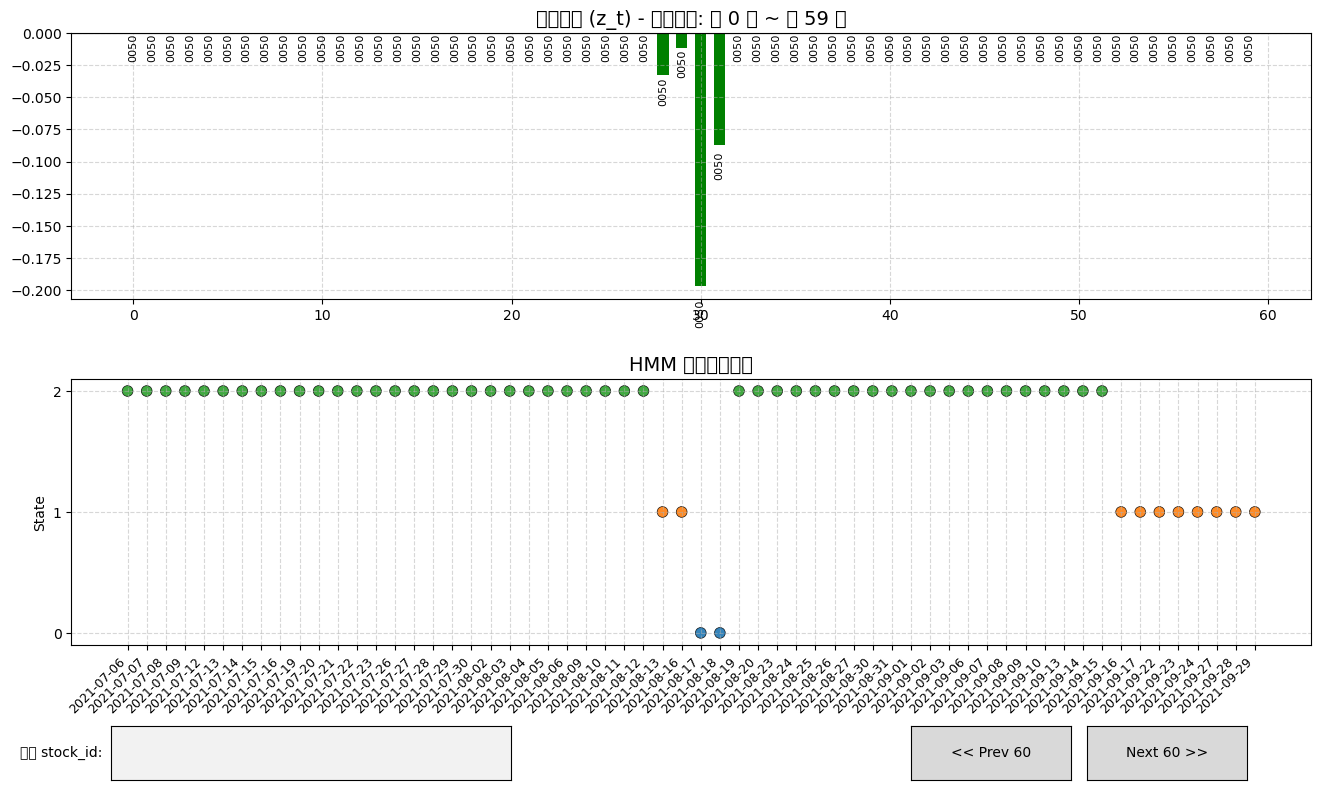

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, TextBox
import matplotlib.colors as mcolors

# ==========================================
# 1. 讀取資料與前置處理
# ==========================================
# 讀取 Parquet 與 NPZ
df = pd.read_parquet('../data/preprocessed_data/no standardize/final_vectors_train.parquet')
hmm_params = np.load('../outputs/result_no_standardize/trained_hmm_params.npz')
states = hmm_params['decoded_states']

# 將狀態合併進 DataFrame 方便我們一起切片
# (假設 states 長度與 df 長度完全一致)
df['State'] = states

# 為每個獨立的狀態配置一個顏色 (使用內建的 tab10 色票讓顏色比較好看)
unique_states = np.unique(states)
cmap = plt.get_cmap('tab10')
state_colors = {state: cmap(i % 10) for i, state in enumerate(unique_states)}

# ==========================================
# 2. 設定互動視窗與全域變數
# ==========================================
WINDOW_SIZE = 60
current_idx = 0  # 紀錄目前顯示區間的起始索引

# 建立畫布，預留下方空間給按鈕與搜尋欄
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(16, 9))
plt.subplots_adjust(bottom=0.2, hspace=0.3) 

# ==========================================
# 3. 定義繪圖函數
# ==========================================
def draw_chart():
    ax1.clear()
    ax2.clear()
    
    # 取出目前視窗內的 60 筆資料
    sub_df = df.iloc[current_idx : current_idx + WINDOW_SIZE].copy()
    
    # 若已經沒有資料則提早返回
    if sub_df.empty:
        return
        
    x_positions = np.arange(len(sub_df)) # 用連續整數作為 X 軸，確保等距
    
    # ----- 上半部：z_t (淨買賣超) 柱狀圖 -----
    # 大於 0 為買超 (紅)，小於等於 0 為賣超 (綠)
    colors = ['red' if val > 0 else 'green' for val in sub_df['z_t']]
    bars = ax1.bar(x_positions, sub_df['z_t'], color=colors, width=0.6)
    
    # 在柱狀圖上標示 stock_id
    for i, (idx, row) in enumerate(sub_df.iterrows()):
        val = row['z_t']
        stock_id = str(row['stock_id'])
        
        # 決定文字標籤的位置 (正值在上方，負值在下方)
        y_pos = val + (val * 0.05) if val > 0 else val + (val * 0.05)
        va_align = 'bottom' if val > 0 else 'top'
        
        ax1.text(i, y_pos, stock_id, ha='center', va=va_align, 
                 fontsize=8, rotation=90, color='black')

    ax1.set_title(f'淨買賣超 (z_t) - 顯示範圍: 第 {current_idx} 筆 ~ 第 {current_idx + len(sub_df) - 1} 筆', fontsize=14)
    ax1.axhline(0, color='black', linewidth=0.8) # 畫一條 0 的基準線
    ax1.grid(True, linestyle='--', alpha=0.5)

    # ----- 下半部：預測狀態 (States) -----
    c_list = [state_colors[s] for s in sub_df['State']]
    ax2.scatter(x_positions, sub_df['State'], c=c_list, s=60, alpha=0.9, edgecolors='black', linewidth=0.5)
    
    ax2.set_title('HMM 模型預測狀態', fontsize=14)
    ax2.set_yticks(unique_states)
    ax2.set_ylabel('State')
    ax2.grid(True, linestyle='--', alpha=0.5)

    # ----- 設定 X 軸標籤 (日期) -----
    # 將日期轉為字串並取前 10 碼 (YYYY-MM-DD)
    date_labels = sub_df['date'].astype(str).str[:10].tolist()
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(date_labels, rotation=45, ha='right', fontsize=9)
    
    # 重繪畫布
    fig.canvas.draw_idle()

# ==========================================
# 4. 定義按鈕與搜尋列行為
# ==========================================
def go_next(event):
    global current_idx
    if current_idx + WINDOW_SIZE < len(df):
        current_idx += WINDOW_SIZE
        draw_chart()

def go_prev(event):
    global current_idx
    if current_idx - WINDOW_SIZE >= 0:
        current_idx -= WINDOW_SIZE
    else:
        current_idx = 0
    draw_chart()

def search_stock(text):
    global current_idx
    # 搜尋符合該 stock_id 的第一筆資料索引
    # 將欄位與輸入都轉成字串來比對，避免型態不一致(int/str)的問題
    matches = df[df['stock_id'].astype(str) == text].index
    if len(matches) > 0:
        current_idx = matches[0] # 跳轉到該 stock_id 出現的第一個位置
        draw_chart()
        print(f"✅ 已跳轉至 stock_id: {text}")
    else:
        print(f"❌ 找不到 stock_id: {text}")

# ==========================================
# 5. 放置 UI 元件
# ==========================================
# [左, 下, 寬, 高]
ax_prev = plt.axes([0.65, 0.05, 0.1, 0.06])
ax_next = plt.axes([0.76, 0.05, 0.1, 0.06])
ax_search = plt.axes([0.15, 0.05, 0.25, 0.06])

btn_prev = Button(ax_prev, '<< Prev 60')
btn_next = Button(ax_next, 'Next 60 >>')
txt_search = TextBox(ax_search, '搜尋 stock_id: ', initial='')

# 綁定事件
btn_prev.on_clicked(go_prev)
btn_next.on_clicked(go_next)
txt_search.on_submit(search_stock)

# 初始化第一次繪圖
draw_chart()
plt.show()

In [46]:
states

array([2, 2, 2, ..., 2, 1, 2], shape=(951068,))

In [47]:
len(df)

1240124

In [3]:
import os
from dotenv import load_dotenv
import pandas as pd
from FinMind.data import DataLoader

# 載入 API key
load_dotenv()
token = os.environ["FINMIND_API_KEY"]

# 初始化 API
api = DataLoader()
api.login_by_token(api_token=token)

# 取得 1470 在 2026-03-02 的交易資料
df = api.taiwan_stock_trading_daily_report(
    securities_trader_id="1440",
    date="2026-03-02",
)

# 篩選華邦電 2344
df_2344 = df[df["stock_id"] == "2344"]

# 計算進出金額
if not df_2344.empty:
    df_2344["buy_amount"] = df_2344["buy"] * df_2344["price"]
    df_2344["sell_amount"] = df_2344["sell"] * df_2344["price"]
    df_2344["net_buy"] = df_2344["buy"] - df_2344["sell"]
    df_2344["net_buy_amount"] = df_2344["buy_amount"] - df_2344["sell_amount"]

print(df_2344)

2026-03-02 22:22:37.736 | INFO     | FinMind.data.finmind_api:login_by_token:84 - Login success
2026-03-02 22:22:37.795 | INFO     | FinMind.data.finmind_api:login_by_token:84 - Login success
2026-03-02 22:22:37.796 | INFO     | FinMind.data.finmind_api:get_data:153 - download Dataset.TaiwanStockInfo, data_id: 
2026-03-02 22:22:38.201 | INFO     | FinMind.data.finmind_api:get_data:153 - download Dataset.TaiwanStockPrice, data_id: 
2026-03-02 22:22:40.866 | INFO     | FinMind.data.finmind_api:get_data:153 - download Dataset.TaiwanStockTradingDailyReport, data_id: 


     securities_trader  price      buy    sell securities_trader_id stock_id  \
2348                美林  115.0     1000   80000                 1440     2344   
2349                美林  115.5        0  230000                 1440     2344   
2350                美林  116.0        0   51000                 1440     2344   
2351                美林  117.0        0   89000                 1440     2344   
2352                美林  117.5        0  275600                 1440     2344   
2353                美林  118.0        0   97000                 1440     2344   
2354                美林  119.5        0  137000                 1440     2344   
2355                美林  120.0   152000    1000                 1440     2344   
2356                美林  120.5   619000       0                 1440     2344   
2357                美林  121.0    93000       0                 1440     2344   
2358                美林  121.5    67000   74000                 1440     2344   
2359                美林  122.0    38000  

In [6]:
df_3037 = df[df["stock_id"] == "3037"]


In [ ]:
df_3037.to_csv("test.csv", index=False, encoding="utf-8-sig")

: 

In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
print(df_3037)

     securities_trader  price    buy   sell securities_trader_id stock_id        date
5130                美林  463.5  77000      0                 1440     3037  2026-03-02
5131                美林  467.0   1000      0                 1440     3037  2026-03-02
5132                美林  467.5   3000      0                 1440     3037  2026-03-02
5133                美林  469.0   4000      0                 1440     3037  2026-03-02
5134                美林  469.5   1000      0                 1440     3037  2026-03-02
...                ...    ...    ...    ...                  ...      ...         ...
5191                美林  499.5  22000      0                 1440     3037  2026-03-02
5192                美林  500.0  14000  54000                 1440     3037  2026-03-02
5193                美林  501.0  20000   1000                 1440     3037  2026-03-02
5194                美林  502.0   3000      0                 1440     3037  2026-03-02
5195                美林  503.0   8000      0           